In [1]:
import os
import sys
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [2]:
from config import config_loader as config_loader
from src.data.preprocessing import load_and_filter_catalog
import numpy as np

In [3]:
def load_rf_config(project_root):
    import os
    from src.utils.file_utils import create_save_dir, save_args_to_json
    from config.config_loader import load_args_from_yaml


    args = load_args_from_yaml(os.path.join(project_root, 'config/classifier.yaml'))

    # 添加 RF 专用字段
    Mag_elaps = [4, 4.5, 5, 5.5]
    feature_cols = [
        'Num', 'Mag_max', 'Mag_mean', 'beta', 'b_lsq', 'a_lsq',
        'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
        'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
        'zvalue'
    ] + [f"T_elaps{Mag}" for Mag in Mag_elaps]

    args.Mag_elaps = Mag_elaps
    args.feature_cols = list(set(feature_cols))
    args.dMag = 0.1
    args_dict = OmegaConf.to_container(args, resolve=True)
   
    args.save_dir = create_save_dir(os.path.join(project_root,'checkpoints') , model_name='rf',args_dict=args_dict )
    args_dict.pop("save_dir", None)


    for key in list(args_dict.keys()):
        if key in {
            "model", "batch_size", "warmup_ratio", "learning_rate", "weight_decay",
            "scheduler_type", "scheduler_factor", "scheduler_patience", "scheduler_threshold",
            "scheduler_min_lr", "d_model", "d_rnn", "d_inner", "n_layers", "n_head", "d_k",
            "d_v", "t_dropout", "attn_type", "mlp_out", "mlp_dropout", "mlp_hdw", "epochs",
            "cuda_id",
        }:
            del args_dict[key]
    save_args_to_json(args_dict, args.save_dir)
    return args


In [4]:
args = load_rf_config(project_root)

In [5]:
args.save_dir

'/root/autodl-tmp/chuandian_eq/checkpoints/rf_27e19ac9'

In [6]:
base_dir = os.path.join(project_root,  f"data/{args.dataset}")
df = load_and_filter_catalog(base_dir, Mc=args.Mc)

CSV files found: ['SaltonSea.csv', 'catalog_SaltonSea.csv', 'processed_SaltonSea.csv']


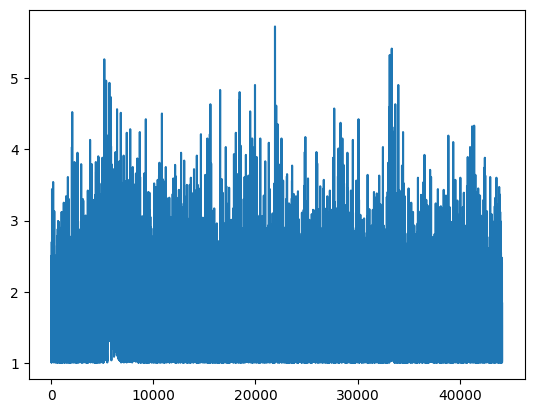

In [7]:
plt.plot(df['Magnitude'])

In [8]:
import src.features.seismic_features as sf
# features_df, num_mag = sf.calculate_seismic_features(
#     df.to_numpy(), 
#     Mc=args.Mc, 
#     Mf=args.Mf, 
#     Twindow=args.Twindow, 
#     Tfore=args.Tfore, 
#     dt=args.dt, 
#     dMag=args.dMag, 
#     Mag_elaps=args.Mag_elaps, 
#     L_max=60,
#     context_len=args.context_len,
# )

In [9]:
from sklearn.preprocessing import MinMaxScaler

def preprocess_data(features_df, feature_cols):
    # 特征缩放
    scaler = MinMaxScaler()
    feature = scaler.fit_transform(features_df[feature_cols])
    
    # 构造标签
    y = np.full(len(features_df), np.nan)
    y[features_df['shock_len'].values > 0] = 1
    y[features_df['Negative'].values == 1] = 0
    
    # 过滤掉无效样本
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]
    
    print(f"正样本数量: {np.sum(y == 1)}")
    print(f"负样本数量: {np.sum(y == 0)}")
    
    return feature, y

# feature, y = preprocess_data(features_df, args.feature_cols)

In [10]:
def split_dataset(feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=False,time_order = ('train', 'val', 'test')):
    from src.data.data_utils import get_split_indices
    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=train_ratio, val_ratio=val_ratio, seed=seed, by_time=by_time,time_order=time_order
    )

    # 根据索引划分数据
    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    return f_train, f_val, f_test, y_train, y_val, y_test

# f_train, f_val, f_test, y_train, y_val, y_test = split_dataset(
#     feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time
# )

In [11]:
def print_sample_distribution(y, dataset_name):
    positive_samples = np.sum(y == 1)
    negative_samples = np.sum(y == 0)
    total_samples = len(y)
    positive_ratio = positive_samples / total_samples
    negative_ratio = negative_samples / total_samples

    print(f"Positive samples: {positive_samples}, Negative samples: {negative_samples}")
    print(f"Total samples: {total_samples}, Positive ratio: {positive_ratio:.2f}, Negative ratio: {negative_ratio:.2f}")
    print()

# # 打印每个数据集的样本分布
# print_sample_distribution(y_train, "训练集")
# print_sample_distribution(y_val, "验证集")
# print_sample_distribution(y_test, "测试集")


In [12]:
def prepare_data_rf(args, base_dir=base_dir):
    import src.features.seismic_features as sf
    from src.data.preprocessing import load_and_filter_catalog
    from src.data.data_utils import get_split_indices
    from src.utils.file_utils import save_or_load_data
    from sklearn.preprocessing import MinMaxScaler
    import numpy as np

    # 加载并过滤地震目录
    df = load_and_filter_catalog(base_dir, Mc=args.Mc)

    # 缓存/生成 seismic features
    def generate_data():
        features_df, num_mag = sf.calculate_seismic_features(
            df.to_numpy(),
            Mc=args.Mc,
            Mf=args.Mf,
            Twindow=args.Twindow,
            Tfore=args.Tfore,
            dt=args.dt,
            dMag=args.dMag,
            Mag_elaps=args.Mag_elaps,
            L_max=60,
            context_len=args.context_len,
        )
        return {
            "features_df": features_df,
            "num_mag": num_mag
        }

    cached = save_or_load_data(
        base_path=base_dir,
        generate_fn=generate_data,
        sub_dir="processed/rf_classifier",
        prefix="rf",
        Mc=args.Mc,
        Mf=args.Mf,
        Twindow=args.Twindow,
        Tfore=args.Tfore,
        dt=args.dt,
        dMag=args.dMag,
        Mag_elaps=args.Mag_elaps,
        context_len=args.context_len
    )

    features_df = cached["features_df"]
    num_mag = cached["num_mag"]

    # 特征缩放 + 标签构建
    scaler = MinMaxScaler()
    # feature = scaler.fit_transform(features_df[args.feature_cols])
    feature = features_df[args.feature_cols].values

    y = np.full(len(features_df), np.nan)
   
   
    y[features_df["shock_len"].values > 0] = 1
    y[features_df["Negative"].values == 1] = 0
    
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]

    # 划分数据集
    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time, time_order=args.time_order
    )

    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    f_train = scaler.fit_transform(f_train)
    f_val = scaler.transform(f_val)
    
    f_test = scaler.transform(f_test)
    # 打印样本分布
    print_sample_distribution(y_train, "训练集")
    print_sample_distribution(y_val, "验证集")
    print_sample_distribution(y_test, "测试集")

    return df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag

In [13]:
df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag = prepare_data_rf(args)

CSV files found: ['SaltonSea.csv', 'catalog_SaltonSea.csv', 'processed_SaltonSea.csv']
[✱] Processing and saving new data to: /root/autodl-tmp/chuandian_eq/data/QTMSaltonSea/processed/rf_classifier/rf_Mag_elaps_[4, 4.5, 5, 5.5]_Mc_0.6_Mf_3.8_Tfore_75_Twindow_150_context_len_1_dMag_0.1_dt_5.pkl
Positive samples: 238, Negative samples: 217
Total samples: 455, Positive ratio: 0.52, Negative ratio: 0.48

Positive samples: 35, Negative samples: 21
Total samples: 56, Positive ratio: 0.62, Negative ratio: 0.38

Positive samples: 15, Negative samples: 43
Total samples: 58, Positive ratio: 0.26, Negative ratio: 0.74



In [14]:
features_df

,t,Num,Mag_max,Mag_max_obs,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,...,prob_x7_lsq,prob_x7_mlk,zvalue,beta,shock_len,Negative,T_elaps4,T_elaps4.5,T_elaps5,T_elaps5.5
0,150.870656,597.0,3.54,3.12,1.440385,1.659800,1.719115,1.285667,28.492117,0.516780,...,0.000010,0.028162,0.119751,0.550219,0.0,1.0,NaN,NaN,NaN,NaN
1,155.870656,847.0,3.54,3.12,1.456505,1.677807,1.876982,1.302494,28.902378,0.507054,...,0.000009,0.030119,-0.532497,6.650557,0.0,1.0,NaN,NaN,NaN,NaN
2,160.870656,930.0,3.54,3.12,1.450108,1.694331,1.900692,1.332795,29.377120,0.510870,...,0.000008,0.029335,-0.820121,8.610455,0.0,1.0,NaN,NaN,NaN,NaN
3,165.870656,925.0,3.54,3.12,1.449157,1.690277,1.900605,1.327096,29.258646,0.511442,...,0.000008,0.029220,-0.767615,9.514621,0.0,1.0,NaN,NaN,NaN,NaN
4,170.870656,933.0,3.54,3.12,1.445895,1.691945,1.898997,1.332027,29.305128,0.513414,...,0.000008,0.028824,-1.102194,11.059462,0.0,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,3555.870656,590.0,3.60,3.12,1.472966,0.945134,1.757296,0.409737,7.439813,0.497493,...,0.001461,0.032175,-1.220433,7.422824,0.0,1.0,363.729019,1855.675093,1855.997071,2659.685261
682,3560.870656,589.0,3.60,3.12,1.470509,0.944137,1.755391,0.409402,7.424260,0.498897,...,0.001471,0.031865,-1.384062,7.138401,0.0,1.0,368.729019,1860.675093,1860.997071,2664.685261
683,3565.870656,588.0,3.60,3.12,1.466361,0.942600,1.753067,0.408963,7.400198,0.501286,...,0.001487,0.031343,-1.281982,7.761795,0.0,1.0,373.729019,1865.675093,1865.997071,2669.685261
684,3570.870656,593.0,3.60,3.12,1.468331,0.943749,1.759278,0.409535,7.416506,0.500149,...,0.001475,0.031590,-0.573835,4.326519,0.0,1.0,378.729019,1870.675093,1870.997071,2674.685261


In [15]:
print(features_df.columns)

Index(['t', 'Num', 'Mag_max', 'Mag_max_obs', 'Mag_mean', 'b_lsq', 'a_lsq',
       'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
       'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
       'zvalue', 'beta', 'shock_len', 'Negative', 'T_elaps4', 'T_elaps4.5',
       'T_elaps5', 'T_elaps5.5'],
      dtype='object')


In [16]:
print(features_df['zvalue'])

0      0.119751
1     -0.532497
2     -0.820121
3     -0.767615
4     -1.102194
         ...   
681   -1.220433
682   -1.384062
683   -1.281982
684   -0.573835
685   -1.204777
Name: zvalue, Length: 686, dtype: float64


In [17]:
features_df[features_df['Num']==min(features_df['Num'])]

,t,Num,Mag_max,Mag_max_obs,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,...,prob_x7_lsq,prob_x7_mlk,zvalue,beta,shock_len,Negative,T_elaps4,T_elaps4.5,T_elaps5,T_elaps5.5
548,2890.870656,384.0,3.28,3.6,1.432839,1.819684,1.671412,1.405794,29.545627,0.521463,...,0.000003,0.027265,0.254011,-0.087581,0.0,1.0,193.734897,1190.675093,1190.997071,1994.685261


In [18]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(f_train, y_train)
y_prob = rf.predict_proba(f_val)[:, 1]  # 取正类的概率

In [19]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

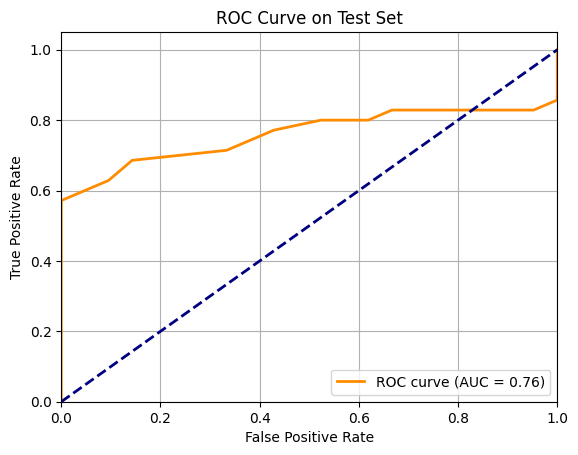

In [20]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 参考线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(args.save_dir, 'roc_curve.png'))
plt.show()


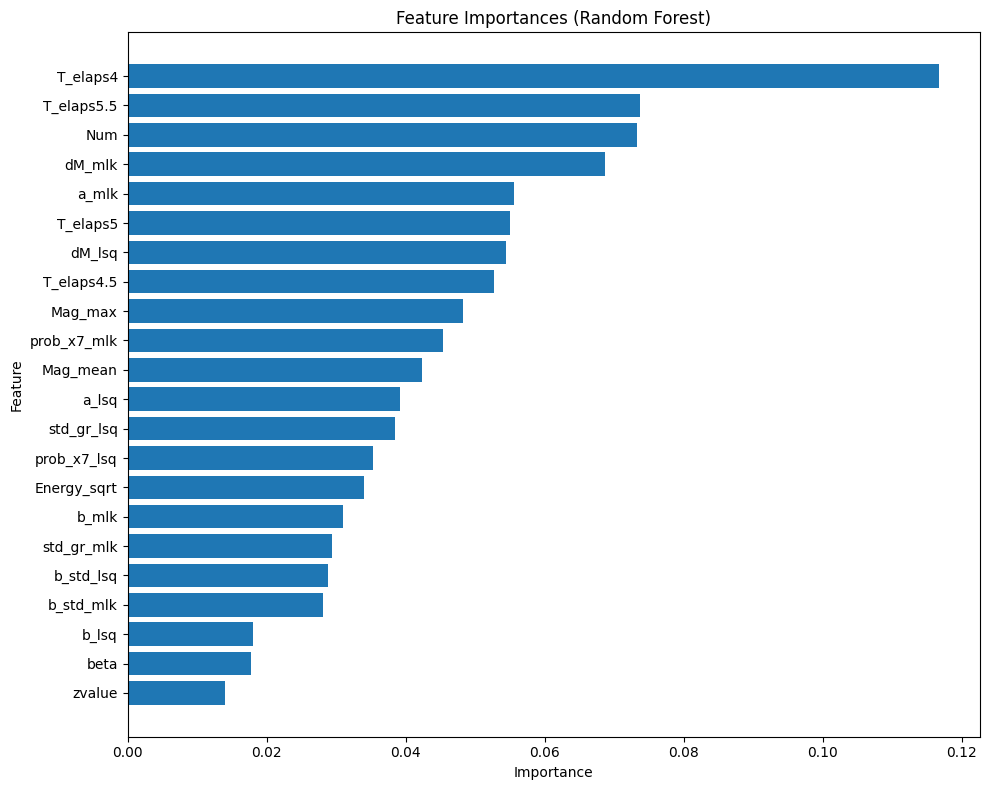

In [21]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[int(i)] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align="center")
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.gca().invert_yaxis()  
plt.savefig(os.path.join(args.save_dir, 'feature_importances.png'))
plt.show()